In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("/content/cleaned_data.csv")

In [8]:
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], format='%Y-%m-%d %H:%M:%S')
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], format='%Y-%m-%d %H:%M:%S')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97731 entries, 0 to 97730
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SN              97731 non-null  int64         
 1   Train_No        97731 non-null  int64         
 2   Station_Code    97731 non-null  object        
 3   1A              97731 non-null  int64         
 4   2A              97731 non-null  int64         
 5   3A              97731 non-null  int64         
 6   SL              97731 non-null  int64         
 7   Station_Name    97731 non-null  object        
 8   Route_Number    97731 non-null  int64         
 9   Arrival_time    97731 non-null  datetime64[ns]
 10  Departure_Time  97731 non-null  datetime64[ns]
 11  Distance        97731 non-null  int64         
dtypes: datetime64[ns](2), int64(8), object(2)
memory usage: 8.9+ MB
None


In [14]:
train_journey_info = df.sort_values(by=['Train_No', 'SN']).groupby('Train_No').agg(
    Source=('Station_Name', 'first'),
    Destination=('Station_Name', 'last')
).reset_index()

df = pd.merge(df, train_journey_info, on='Train_No', how='left')

# Display the first few rows to verify the new columns
print(df[['Train_No', 'Station_Name', 'Source_x', 'Destination_x', 'SN']].head())

   Train_No  Station_Name      Source_x Destination_x  SN
0       107  SAWANTWADI R  SAWANTWADI R   MADGOAN JN.   1
1       107        THIVIM  SAWANTWADI R   MADGOAN JN.   2
2       107       KARMALI  SAWANTWADI R   MADGOAN JN.   3
3       107   MADGOAN JN.  SAWANTWADI R   MADGOAN JN.   4
4       108   MADGOAN JN.   MADGOAN JN.  SAWANTWADI R   1


In [33]:
def train_enquiry_system():

    print("\n====== TRAIN ENQUIRY SYSTEM ======")

    source = input("Enter Source Station: ")
    destination = input("Enter Destination Station: ")

    # Modify filtering for case-insensitive partial matching
    result = df[
        (df['Source_x'].str.contains(source, case=False, na=False)) &
        (df['Destination_x'].str.contains(destination, case=False, na=False))
    ]

    if result.empty:
        print("\nNo direct trains found.")
        return [], [] # Return empty lists if no trains found

    trains = result['Train_No'].unique()

    print("\n AVAILABLE TRAINS:\n")

    durations = []
    names = []

    # Loop through each train
    for train in trains:
        train_data = df[df['Train_No'] == train].sort_values(by='SN')

        print(f"\n Train: {train}")

        # Route details
        print(" Route Details:")
        for _, row in train_data.iterrows():
            print(f"   {row['Station_Name']} | Arr: {row['Arrival_time'].time()} | Dep: {row['Departure_Time'].time()}")

        # Duration calculation
        start = train_data.iloc[0]['Departure_Time']
        end = train_data.iloc[-1]['Arrival_time']
        duration = (end - start).total_seconds() / 3600

        print(f" Estimated Journey Duration: {round(duration,2)} hours")
        print("-" * 40)

        names.append(train)
        durations.append(duration)

    return names, durations


====== TRAIN ENQUIRY SYSTEM ======
Enter Source Station: MADGOAN
Enter Destination Station: SAWANTWADI 

 AVAILABLE TRAINS:


 Train: 108
 Route Details:
   MADGOAN JN. | Arr: 00:00:00 | Dep: 20:30:00
   KARMALI | Arr: 21:04:00 | Dep: 21:06:00
   THIVIM | Arr: 21:26:00 | Dep: 21:28:00
   SAWANTWADI R | Arr: 22:25:00 | Dep: 00:00:00
 Estimated Journey Duration: 1.92 hours
----------------------------------------


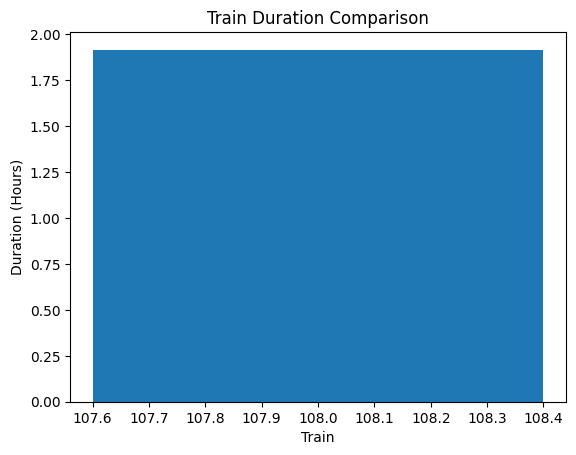

In [ ]:
# RUN LOOP (interactive)
# -----------------------------------------
while True:
    names, durations = train_enquiry_system()

    # Only plot if trains were found
    if names and durations:
        plt.figure()
        plt.bar(names, durations)
        plt.title("Train Duration Comparison")
        plt.xlabel("Train")
        plt.ylabel("Duration (Hours)")
        plt.show()

    cont = input("\nDo you want to search again? (yes/no): ")
    if cont.lower() != "yes":
        print("Thank you for using Train Enquiry System ")
        break